In [ ]:
import pandas as pd
import requests

def get_census_json(url):
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    data = r.json()
    return pd.DataFrame(data[1:], columns=data[0])

# 1) Median household income from ACS 5-year detailed tables
income_url = (
    "https://api.census.gov/data/2022/acs/acs5"
    "?get=NAME,B19013_001E&for=county:*"
)

income_df = get_census_json(income_url)
income_df["county_fips"] = income_df["state"] + income_df["county"]
income_df["median_income"] = pd.to_numeric(income_df["B19013_001E"], errors="coerce")
income_df = income_df[["county_fips", "NAME", "median_income"]]

# 2) Poverty rate from ACS 5-year subject tables
poverty_url = (
    "https://api.census.gov/data/2022/acs/acs5/subject"
    "?get=NAME,S1701_C03_001E&for=county:*"
)

poverty_df = get_census_json(poverty_url)
poverty_df["county_fips"] = poverty_df["state"] + poverty_df["county"]
poverty_df["poverty_rate"] = pd.to_numeric(poverty_df["S1701_C03_001E"], errors="coerce")
poverty_df = poverty_df[["county_fips", "poverty_rate"]]

# 3) Merge them
acs_df = income_df.merge(poverty_df, on="county_fips", how="inner")

print(acs_df.shape)
acs_df.head()

(3222, 4)


,county_fips,NAME,median_income,poverty_rate
0,01001,"Autauga County, Alabama",68315,11.4
1,01003,"Baldwin County, Alabama",71039,10.2
2,01005,"Barbour County, Alabama",39712,24.2
3,01007,"Bibb County, Alabama",50669,20.6
4,01009,"Blount County, Alabama",57440,14.2


In [ ]:
# Clean income
acs_df["median_income"] = pd.to_numeric(acs_df["median_income"], errors="coerce")

# Remove invalid values
acs_df = acs_df[
    (acs_df["median_income"] > 0) &
    (acs_df["median_income"] < 200000)  # reasonable upper bound
]

# Clean everything in one go
acs_df["median_income"] = pd.to_numeric(acs_df["median_income"], errors="coerce")
acs_df["poverty_rate"] = pd.to_numeric(acs_df["poverty_rate"], errors="coerce")

acs_df = acs_df.dropna(subset=["median_income", "poverty_rate"])

acs_df = acs_df[
    (acs_df["median_income"] > 0) &
    (acs_df["median_income"] < 200000) &
    (acs_df["poverty_rate"] >= 0) &
    (acs_df["poverty_rate"] <= 60)
]

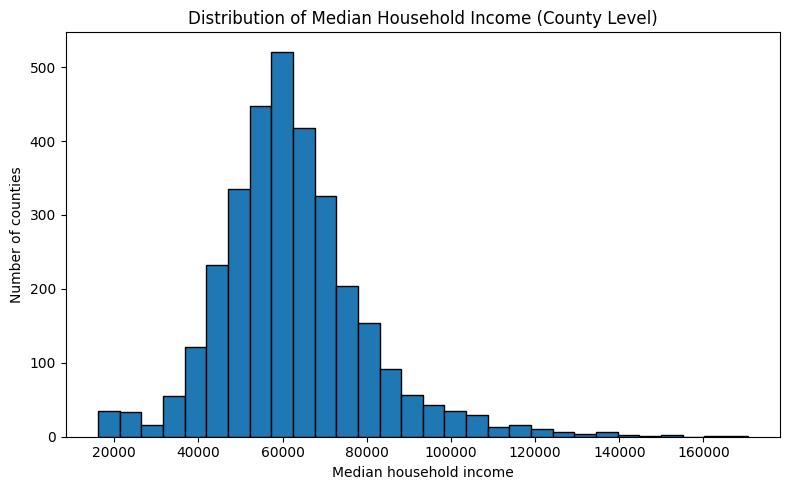

In [ ]:
import matplotlib.pyplot as plt

# Median income distribution
plt.figure(figsize=(8,5))
plt.hist(acs_df["median_income"].dropna(), bins=30, edgecolor="black")
plt.title("Distribution of Median Household Income (County Level)")
plt.xlabel("Median household income")
plt.ylabel("Number of counties")
plt.tight_layout()
plt.savefig("hist_income.png", dpi=300)
plt.show()



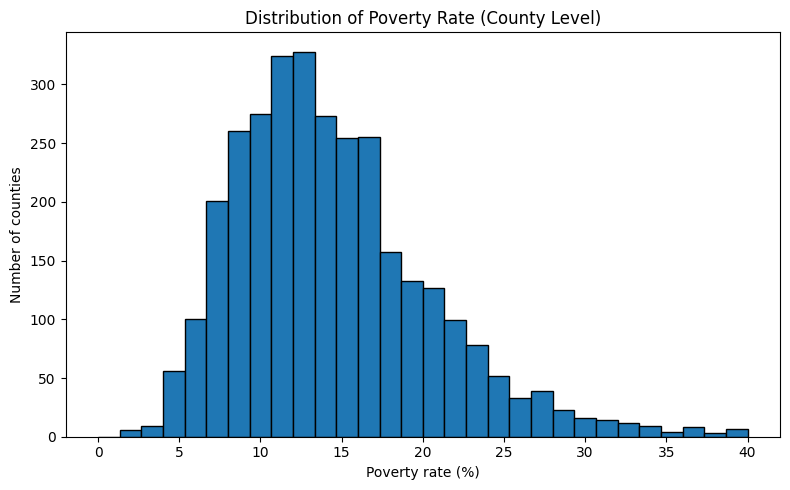

In [ ]:
# Poverty rate distribution
plt.figure(figsize=(8,5))

plt.hist(
    acs_df["poverty_rate"].dropna(),
    bins=30,
    range=(0, 40),  # focus on realistic range
    edgecolor="black"
)

plt.title("Distribution of Poverty Rate (County Level)")
plt.xlabel("Poverty rate (%)")
plt.ylabel("Number of counties")

plt.tight_layout()
plt.savefig("hist_poverty_fixed.png", dpi=300)
plt.show()


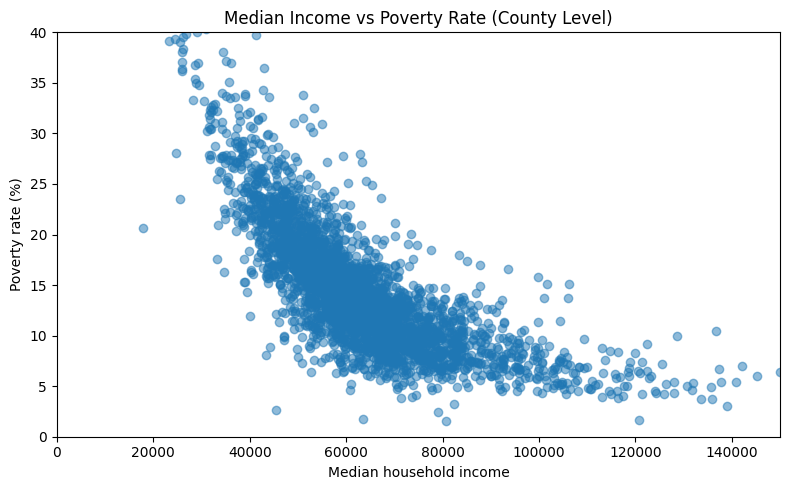

In [ ]:
# Median Income Vs Poverty Rate
plt.figure(figsize=(8,5))

plt.scatter(
    acs_df["median_income"],
    acs_df["poverty_rate"],
    alpha=0.5
)

plt.xlim(0, 150000)  # zoom into realistic range
plt.ylim(0, 40)

plt.title("Median Income vs Poverty Rate (County Level)")
plt.xlabel("Median household income")
plt.ylabel("Poverty rate (%)")

plt.tight_layout()
plt.savefig("scatter_income_vs_poverty_fixed.png", dpi=300)
plt.show()

In [ ]:
import pandas as pd

# Load correct sheet
usda = pd.read_excel("FoodAccessResearchAtlasData2019.xlsx", sheet_name=1)

usda.head()

,Field,LongName,Description
0,CensusTract,Census tract,Census tract number
1,State,State,State name
2,County,County,County name
3,Urban,Urban tract,Flag for urban tract
4,POP2010,"Population, tract total",Population count from 2010 census


In [ ]:
usda = pd.read_excel(
    "FoodAccessResearchAtlasData2019.xlsx",
    sheet_name="Food Access Research Atlas"
)

usda.columns = usda.columns.str.strip()

usda = usda[[
    "CensusTract",
    "Pop2010",
    "LAPOP1_10"
]]

usda["county_fips"] = usda["CensusTract"].astype(str).str[:5]

usda["Pop2010"] = pd.to_numeric(usda["Pop2010"], errors="coerce")
usda["LAPOP1_10"] = pd.to_numeric(usda["LAPOP1_10"], errors="coerce")

usda_county = usda.groupby("county_fips", as_index=False).agg(
    total_population=("Pop2010", "sum"),
    low_access_population=("LAPOP1_10", "sum")
)

usda_county["low_access_share"] = (
    usda_county["low_access_population"] /
    usda_county["total_population"]
)

usda.head()

,CensusTract,Pop2010,LAPOP1_10,county_fips
0,1001020100,1912,1896.493338,10010
1,1001020200,2170,1260.991651,10010
2,1001020300,3373,1551.703935,10010
3,1001020400,4386,1363.466885,10010
4,1001020500,10766,2643.095161,10010


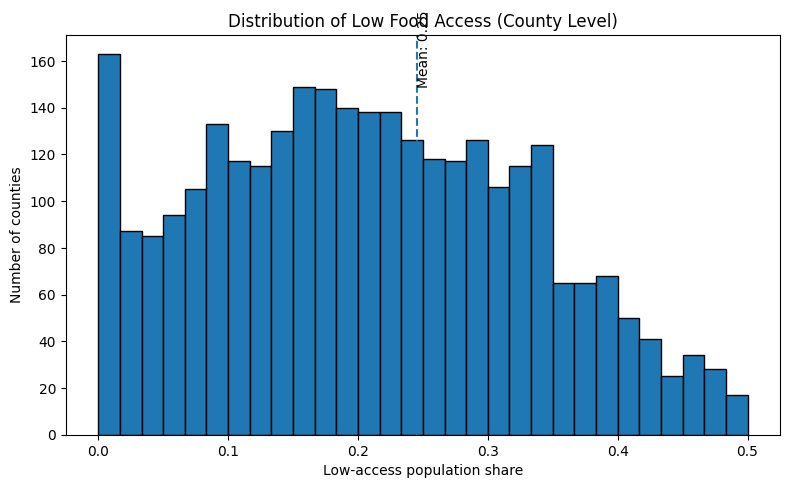

In [ ]:
import numpy as np

mean_val = usda_county["low_access_share"].mean()

plt.figure(figsize=(8,5))
plt.hist(usda_county["low_access_share"].dropna(), bins=30, range=(0,0.5), edgecolor="black")

plt.axvline(mean_val, linestyle="--")
plt.text(mean_val, 150, f"Mean: {mean_val:.2f}", rotation=90)

plt.title("Distribution of Low Food Access (County Level)")
plt.xlabel("Low-access population share")
plt.ylabel("Number of counties")

plt.tight_layout()
plt.savefig("hist_food_access_with_mean.png", dpi=300)
plt.show()

In [ ]:
import pandas as pd

url = "https://data.cdc.gov/resource/swc5-untb.csv?$limit=50000"
places = pd.read_csv(url)

print(places.head())
print(places.columns)

   year stateabbr statedesc locationname datasource         category  \
0  2023        AR  Arkansas         Drew      BRFSS  Health Outcomes   
1  2023        AR  Arkansas       Fulton      BRFSS  Health Outcomes   
2  2023        AR  Arkansas       Howard      BRFSS  Health Outcomes   
3  2023        AR  Arkansas       Miller      BRFSS  Health Outcomes   
4  2023        AR  Arkansas     Ouachita      BRFSS       Disability   

                       measure data_value_unit   data_value_type  data_value  \
0       Arthritis among adults               %  Crude prevalence        29.9   
1  Current asthma among adults               %  Crude prevalence        10.6   
2       Arthritis among adults               %  Crude prevalence        31.2   
3          Stroke among adults               %  Crude prevalence         4.7   
4  Any disability among adults               %  Crude prevalence        42.8   

   ... low_confidence_limit high_confidence_limit  totalpopulation  \
0  ...          

/tmp/ipykernel_9740/3686587891.py:4: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  places = pd.read_csv(url)


In [ ]:
print(places.columns.tolist())

['year', 'stateabbr', 'statedesc', 'locationname', 'datasource', 'category', 'measure', 'data_value_unit', 'data_value_type', 'data_value', 'data_value_footnote_symbol', 'data_value_footnote', 'low_confidence_limit', 'high_confidence_limit', 'totalpopulation', 'totalpop18plus', 'locationid', 'categoryid', 'measureid', 'datavaluetypeid', 'short_question_text', 'geolocation']


In [ ]:
# Make sure measure is lowercase
places["measure"] = places["measure"].str.lower()

# Use locationid as county FIPS
places["county_fips"] = places["locationid"].astype(str).str.zfill(5)

# Extract obesity rows
obesity = places[places["measure"].str.contains("obesity", na=False)][
    ["county_fips", "data_value"]
].rename(columns={"data_value": "obesity"})

# Extract diabetes rows
diabetes = places[places["measure"].str.contains("diabetes", na=False)][
    ["county_fips", "data_value"]
].rename(columns={"data_value": "diabetes"})

# Convert to numeric just in case
obesity["obesity"] = pd.to_numeric(obesity["obesity"], errors="coerce")
diabetes["diabetes"] = pd.to_numeric(diabetes["diabetes"], errors="coerce")

# Merge into one health table
health = obesity.merge(diabetes, on="county_fips", how="inner")

print(health.head())
print(health.shape)

  county_fips  obesity  diabetes
0       08125     28.4      10.9
1       08125     28.4       9.2
2       13047     33.9      10.3
3       13047     33.9      12.5
4       13225     39.3      14.9
(2460, 3)


In [ ]:
merged = acs_df.merge(usda_county, on="county_fips", how="inner")
merged = merged.merge(health, on="county_fips", how="inner")

print(merged.shape)

(1184, 9)


In [ ]:
print(places["locationid"].head())
print(places["measure"].unique()[:20])

0    5043
1    5049
2    5061
3    5091
4    5103
Name: locationid, dtype: int64
['arthritis among adults' 'current asthma among adults'
 'stroke among adults' 'any disability among adults'
 'obesity among adults' 'diagnosed diabetes among adults'
 'depression among adults' 'hearing disability among adults'
 'binge drinking among adults' 'high blood pressure among adults'
 'vision disability among adults' 'mobility disability among adults'
 'self-care disability among adults'
 'frequent mental distress among adults'
 'high cholesterol among adults who have ever been screened'
 'frequent physical distress among adults'
 'colorectal cancer screening among adults aged 45–75 years'
 'no leisure-time physical activity among adults'
 'chronic obstructive pulmonary disease among adults'
 'independent living disability among adults']


In [ ]:
print("ACS:", acs_df.shape)
print("USDA:", usda_county.shape)
print("Health:", health.shape)
print("Merged:", merged.shape)

ACS: (3219, 4)
USDA: (3183, 4)
Health: (2460, 3)
Merged: (1184, 9)


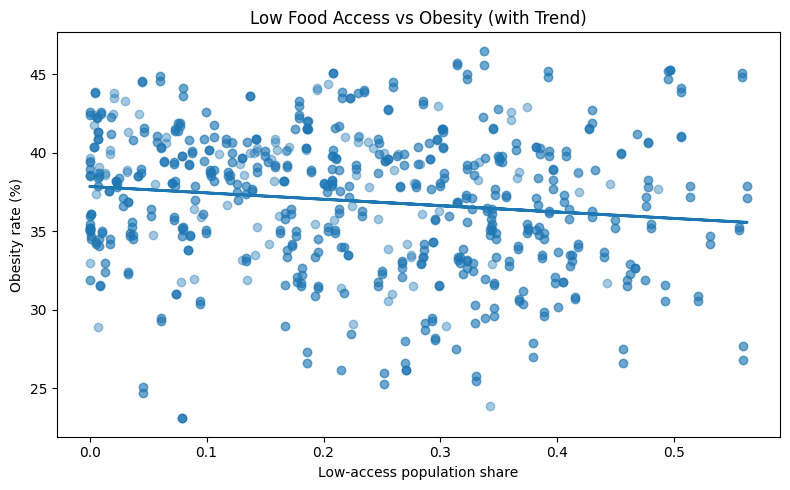

In [ ]:
import numpy as np

x = filtered["low_access_share"]
y = filtered["obesity"]

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.4)
plt.plot(x, p(x), linewidth=2)

plt.title("Low Food Access vs Obesity (with Trend)")
plt.xlabel("Low-access population share")
plt.ylabel("Obesity rate (%)")

plt.tight_layout()
plt.savefig("food_vs_obesity_trend.png", dpi=300)
plt.show()

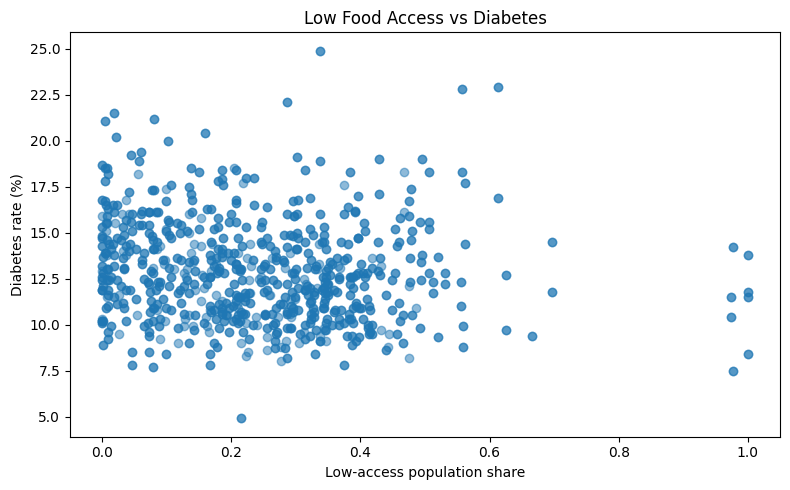

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(merged["low_access_share"], merged["diabetes"], alpha=0.5)

plt.title("Low Food Access vs Diabetes")
plt.xlabel("Low-access population share")
plt.ylabel("Diabetes rate (%)")

plt.tight_layout()
plt.savefig("food_vs_diabetes.png", dpi=300)
plt.show()

/tmp/ipykernel_9740/691724054.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Low", "Mid-Low", "Mid-High", "High"])


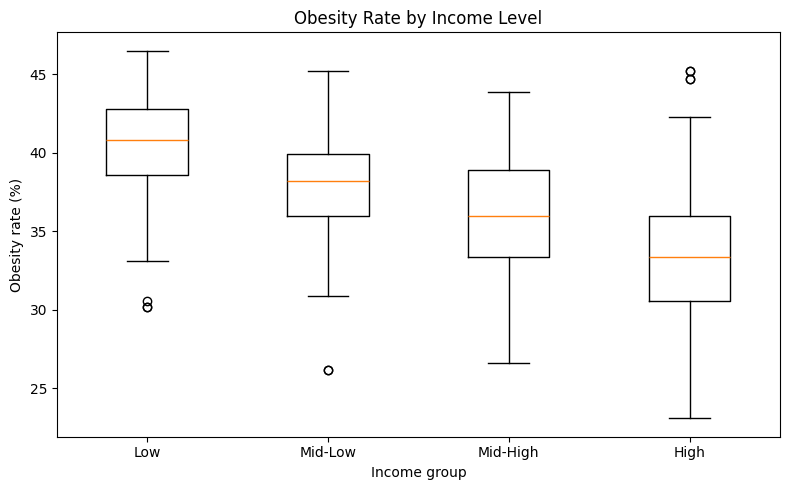

In [ ]:
merged["income_group"] = pd.qcut(
    merged["median_income"], 4,
    labels=["Low", "Mid-Low", "Mid-High", "High"]
)

plt.figure(figsize=(8,5))

data = [
    merged[merged["income_group"] == g]["obesity"].dropna()
    for g in ["Low", "Mid-Low", "Mid-High", "High"]
]

plt.boxplot(data, labels=["Low", "Mid-Low", "Mid-High", "High"])

plt.title("Obesity Rate by Income Level")
plt.xlabel("Income group")
plt.ylabel("Obesity rate (%)")

plt.tight_layout()
plt.savefig("box_obesity_income.png", dpi=300)
plt.show()

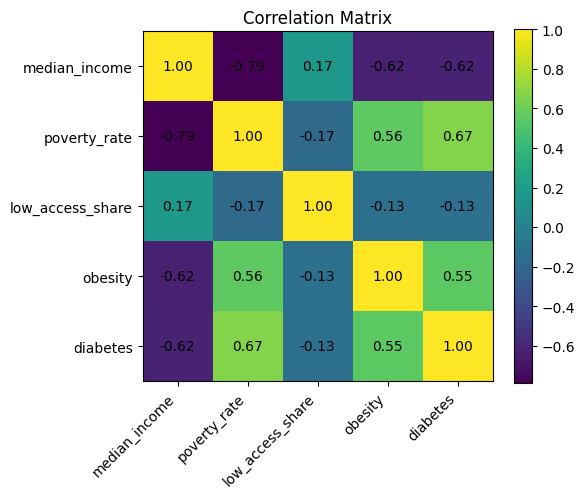

In [ ]:
cols = ["median_income", "poverty_rate", "low_access_share", "obesity", "diabetes"]

corr = merged[cols].corr()

plt.figure(figsize=(6,5))
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(cols)), cols, rotation=45, ha="right")
plt.yticks(range(len(cols)), cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center")

plt.title("Correlation Matrix")

plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=300)
plt.show()